<a href="https://colab.research.google.com/github/mjcolebank/Colebank_REU_2026/blob/main/Metrics_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classification Metrics for Standard and Bayesian Neural Network Classifiers

This notebook explains and implements common performance metrics for binary neural-network classification. It is written with two use cases in mind:

1. **A standard neural network classifier**, where the model has fixed trained weights and returns logits or probabilities.
2. **A Bayesian neural network classifier**, where the model has a posterior distribution over weights and predictions are usually formed by averaging probabilities over posterior samples.

The metrics covered are:

- negative ELBO
- accuracy
- balanced accuracy
- AUROC
- AUPRC
- sensitivity and specificity
- negative log likelihood
- Brier score
- expected calibration error

Throughout this notebook, assume a binary classification problem with labels

$$
y_i \in \{0, 1\}
$$

and predicted probabilities

$$
\hat p_i = P(y_i = 1 \mid x_i).
$$

For a two-class neural network, the model usually returns two logits:

$$
z_i = (z_{i0}, z_{i1})
$$

and the class probabilities are obtained with the softmax function:

$$
P(y_i = c \mid x_i) = \frac{\exp(z_{ic})}{\sum_{k=0}^{1} \exp(z_{ik})}.
$$

## 1. Setup

The code below imports standard packages. The metric implementations use NumPy and scikit-learn. The neural-network prediction helpers use PyTorch. The Bayesian negative ELBO helper assumes Pyro.

If Pyro is not installed, the Bayesian-specific cells can be skipped.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    log_loss,
    brier_score_loss,
    roc_curve,
    precision_recall_curve,
    auc,
)

## 2. Prediction objects used by the metrics

Most metrics require two arrays:

$$
y = (y_1, \ldots, y_N)
$$

and

$$
\hat p = (\hat p_1, \ldots, \hat p_N),
$$

where \(\hat p_i\) is the predicted probability of the positive class, class 1.

For binary classification, the hard predicted class is usually

$$
\hat y_i = \mathbb{1}(\hat p_i \geq \tau),
$$

where \(\tau = 0.5\) is the default threshold.

For a neural network with two softmax outputs, we often instead define

$$
\hat y_i = \arg\max_{c \in \{0,1\}} P(y_i=c \mid x_i).
$$

These are equivalent when the positive class probability threshold is 0.5.

In [2]:
def as_numpy(x):
    """Convert torch tensors or array-like objects to NumPy arrays."""
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def probs_to_predictions(probs, threshold=0.5):
    """
    Convert probabilities to hard class predictions.

    Args:
        probs: Either shape [N] containing P(class 1), or shape [N, 2]
               containing [P(class 0), P(class 1)].
        threshold: Positive-class threshold used if probs has shape [N].

    Returns:
        y_pred: shape [N]
    """
    probs = as_numpy(probs)

    if probs.ndim == 1:
        return (probs >= threshold).astype(int)

    if probs.ndim == 2:
        return np.argmax(probs, axis=1).astype(int)

    raise ValueError("probs must have shape [N] or [N, C].")


def positive_class_probability(probs):
    """
    Extract P(class 1) from either shape [N] or shape [N, 2].
    """
    probs = as_numpy(probs)

    if probs.ndim == 1:
        return probs

    if probs.ndim == 2 and probs.shape[1] == 2:
        return probs[:, 1]

    raise ValueError("For binary metrics, probs must have shape [N] or [N, 2].")

## 3. Collecting predictions from a standard neural network

A standard neural network classifier has a single fitted set of weights, often denoted \(\theta\). The model estimates

$$
P(y \mid x, \theta).
$$

For a PyTorch model, the usual evaluation pipeline is:

1. Set the model to evaluation mode with `model.eval()`.
2. Send batches to the correct device.
3. Compute logits.
4. Convert logits to probabilities with softmax.
5. Store labels and probabilities.

The function below assumes your model returns logits of shape `[batch_size, 2]`.

In [3]:
@torch.no_grad()
def collect_predictions_standard_nn(model, data_loader, device):
    """
    Collect labels and probabilities from a standard deterministic neural network.

    Args:
        model: PyTorch classifier returning logits of shape [batch_size, 2].
        data_loader: DataLoader yielding (x, y).
        device: torch device.

    Returns:
        y_true: shape [N]
        probs: shape [N, 2]
        y_pred: shape [N]
    """
    model.eval()

    all_y = []
    all_probs = []

    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)

        logits = model(x)
        probs = F.softmax(logits, dim=-1)

        all_y.append(y.detach().cpu())
        all_probs.append(probs.detach().cpu())

    y_true = torch.cat(all_y, dim=0).numpy()
    probs = torch.cat(all_probs, dim=0).numpy()
    y_pred = probs.argmax(axis=1)

    return y_true, probs, y_pred

## 4. Collecting predictions from a Bayesian neural network

A Bayesian neural network places a prior distribution over weights:

$$
p(\theta)
$$

and uses the data to form a posterior distribution:

$$
p(\theta \mid \mathcal{D}).
$$

The posterior predictive distribution averages over uncertainty in the weights:

$$
p(y^* \mid x^*, \mathcal{D}) = \int p(y^* \mid x^*, \theta) p(\theta \mid \mathcal{D}) \, d\theta.
$$

In practice, this integral is usually approximated with Monte Carlo samples:

$$
p(y^* \mid x^*, \mathcal{D}) \approx \frac{1}{S} \sum_{s=1}^S p(y^* \mid x^*, \theta^{(s)}),
$$

where

$$
\theta^{(s)} \sim q(\theta)
$$

and \(q(\theta)\) is the variational posterior learned by the guide.

For your Pyro model, the helper below assumes you already have a function named `predict_proba_bayesian(model, guide, x, num_samples)` that returns posterior-averaged probabilities of shape `[batch_size, 2]`.

In [4]:
@torch.no_grad()
def collect_predictions_bayesian_nn(model, guide, data_loader, device, num_samples=100):
    """
    Collect labels and posterior predictive probabilities from a Bayesian neural network.

    This assumes a helper function exists:
        predict_proba_bayesian(model, guide, x, num_samples)

    Args:
        model: PyroModule Bayesian classifier.
        guide: Pyro guide, such as AutoDiagonalNormal(model).
        data_loader: DataLoader yielding (x, y).
        device: torch device.
        num_samples: Number of posterior samples used for prediction.

    Returns:
        y_true: shape [N]
        probs: shape [N, 2]
        y_pred: shape [N]
    """
    model.eval()

    all_y = []
    all_probs = []

    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)

        mean_probs = predict_proba_bayesian(
            model=model,
            guide=guide,
            x=x,
            num_samples=num_samples,
        )

        all_y.append(y.detach().cpu())
        all_probs.append(mean_probs.detach().cpu())

    y_true = torch.cat(all_y, dim=0).numpy()
    probs = torch.cat(all_probs, dim=0).numpy()
    y_pred = probs.argmax(axis=1)

    return y_true, probs, y_pred

## 5. Confusion matrix quantities

For binary classification, many metrics are built from the confusion matrix.

| Quantity | Meaning |
|---|---|
| TP | True positives: true class 1 and predicted class 1 |
| TN | True negatives: true class 0 and predicted class 0 |
| FP | False positives: true class 0 but predicted class 1 |
| FN | False negatives: true class 1 but predicted class 0 |

The confusion matrix is usually written as:

$$
\begin{bmatrix}
TN & FP \\
FN & TP
\end{bmatrix}
$$

In [5]:
def confusion_counts(y_true, y_pred):
    """
    Return TN, FP, FN, TP for binary labels 0 and 1.
    """
    y_true = as_numpy(y_true).astype(int)
    y_pred = as_numpy(y_pred).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return tn, fp, fn, tp

## 6. Accuracy

Accuracy is the fraction of all examples classified correctly:

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}.
$$

Interpretation:

- Accuracy ranges from 0 to 1.
- Higher is better.
- It is easy to understand.
- It can be misleading when classes are imbalanced.

For example, if 90% of patients are class 0, a classifier that always predicts class 0 gets 90% accuracy but has zero sensitivity for class 1.

In [6]:
def compute_accuracy(y_true, y_pred):
    y_true = as_numpy(y_true)
    y_pred = as_numpy(y_pred)
    return np.mean(y_true == y_pred)

## 7. Sensitivity and specificity

Sensitivity is also called recall or the true positive rate:

$$
\text{Sensitivity} = \frac{TP}{TP + FN}.
$$

It answers:

> Among truly positive cases, what fraction did the model detect?

Specificity is the true negative rate:

$$
\text{Specificity} = \frac{TN}{TN + FP}.
$$

It answers:

> Among truly negative cases, what fraction did the model correctly rule out?

Interpretation in a medical classifier:

- High sensitivity means few missed positive cases.
- High specificity means few false alarms.
- The preferred balance depends on the clinical cost of false negatives versus false positives.

In [7]:
def compute_sensitivity_specificity(y_true, y_pred):
    tn, fp, fn, tp = confusion_counts(y_true, y_pred)

    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    return sensitivity, specificity

## 8. Balanced accuracy

Balanced accuracy averages sensitivity and specificity:

$$
\text{Balanced Accuracy} = \frac{1}{2}
\left(
\frac{TP}{TP+FN} + \frac{TN}{TN+FP}
\right).
$$

Interpretation:

- Balanced accuracy ranges from 0 to 1.
- Higher is better.
- It is more informative than ordinary accuracy when the classes are imbalanced.
- A classifier that performs well only on the majority class will have poor balanced accuracy.

In [8]:
def compute_balanced_accuracy(y_true, y_pred):
    sensitivity, specificity = compute_sensitivity_specificity(y_true, y_pred)
    return 0.5 * (sensitivity + specificity)

## 9. AUROC

The receiver operating characteristic curve plots:

$$
\text{TPR}(\tau) = \frac{TP(\tau)}{TP(\tau)+FN(\tau)}
$$

against

$$
\text{FPR}(\tau) = \frac{FP(\tau)}{FP(\tau)+TN(\tau)}
$$

as the classification threshold \(\tau\) varies from 0 to 1.

The AUROC is the area under this curve.

Interpretation:

- AUROC ranges from 0 to 1.
- 0.5 means random ranking.
- 1.0 means perfect ranking.
- AUROC measures how well the model ranks positives above negatives.
- AUROC does not depend on a single classification threshold.

A useful probabilistic interpretation is:

$$
\text{AUROC} = P(\hat p_{\text{positive}} > \hat p_{\text{negative}}),
$$

up to handling of ties.

AUROC can look optimistic under strong class imbalance, so it is often useful to also report AUPRC.

In [9]:
def compute_auroc(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return roc_auc_score(y_true, p1)


def plot_roc_curve(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    fpr, tpr, thresholds = roc_curve(y_true, p1)
    score = roc_auc_score(y_true, p1)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUROC = {score:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate / sensitivity")
    plt.title("ROC curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 10. AUPRC

The precision-recall curve plots precision against recall as the threshold varies.

Precision is:

$$
\text{Precision} = \frac{TP}{TP+FP}.
$$

Recall is the same as sensitivity:

$$
\text{Recall} = \frac{TP}{TP+FN}.
$$

The AUPRC is the area under the precision-recall curve.

Interpretation:

- AUPRC ranges from 0 to 1.
- Higher is better.
- It is especially useful when the positive class is rare.
- The baseline AUPRC is approximately the prevalence of the positive class:

$$
\text{Baseline AUPRC} \approx P(y=1).
$$

For example, if only 10% of examples are positive, an AUPRC of 0.40 may be much better than it first appears.

In [10]:
def compute_auprc(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    if len(np.unique(y_true)) < 2:
        return np.nan

    return average_precision_score(y_true, p1)


def plot_precision_recall_curve(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)

    precision, recall, thresholds = precision_recall_curve(y_true, p1)
    score = average_precision_score(y_true, p1)
    prevalence = np.mean(y_true == 1)

    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, label=f"AUPRC = {score:.3f}")
    plt.hlines(prevalence, 0, 1, linestyle="--", label=f"Baseline = {prevalence:.3f}")
    plt.xlabel("Recall / sensitivity")
    plt.ylabel("Precision")
    plt.title("Precision-recall curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 11. Negative log likelihood

For binary classification, if \(\hat p_i = P(y_i=1 \mid x_i)\), the negative log likelihood is:

$$
\text{NLL} = -\frac{1}{N}\sum_{i=1}^{N}
\left[
    y_i \log(\hat p_i) + (1-y_i)\log(1-\hat p_i)
\right].
$$

This is the same as binary cross-entropy.

For a two-class softmax classifier, it can also be written as:

$$
\text{NLL} = -\frac{1}{N}\sum_{i=1}^{N}\log P(y_i \mid x_i).
$$

Interpretation:

- Lower is better.
- NLL rewards assigning high probability to the correct class.
- NLL penalizes confident wrong predictions very heavily.
- Unlike accuracy, NLL uses the actual predicted probabilities.

For a Bayesian neural network, NLL should be calculated using the posterior predictive probability:

$$
P(y_i \mid x_i, \mathcal{D}) \approx \frac{1}{S}\sum_{s=1}^{S} P(y_i \mid x_i, \theta^{(s)}).
$$

In [11]:
def compute_negative_log_likelihood(y_true, probs, eps=1e-12):
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        p1 = np.clip(probs, eps, 1.0 - eps)
        return -np.mean(y_true * np.log(p1) + (1 - y_true) * np.log(1 - p1))

    if probs.ndim == 2:
        probs = np.clip(probs, eps, 1.0)
        probs = probs / probs.sum(axis=1, keepdims=True)
        return log_loss(y_true, probs, labels=[0, 1])

    raise ValueError("probs must have shape [N] or [N, 2].")

## 12. Brier score

For binary classification, the Brier score is the mean squared error of the predicted probability:

$$
\text{Brier} = \frac{1}{N}\sum_{i=1}^{N}(\hat p_i - y_i)^2.
$$

Interpretation:

- Lower is better.
- A perfect classifier has Brier score 0.
- Brier score measures both discrimination and calibration.
- It is less harsh than NLL for very confident wrong predictions.

Examples:

- If \(y=1\) and $$\hat p=0.9$$, contribution is $$(0.9-1)^2=0.01$$.
- If \(y=1\) and $$\hat p=0.1$$, contribution is $$(0.1-1)^2=0.81$$.

In [12]:
def compute_brier_score(y_true, probs):
    y_true = as_numpy(y_true).astype(int)
    p1 = positive_class_probability(probs)
    return np.mean((p1 - y_true) ** 2)

## 13. Expected calibration error

Calibration asks whether predicted probabilities match observed frequencies.

A well-calibrated model should satisfy:

$$
P(y=1 \mid \hat p = 0.8) \approx 0.8.
$$

Expected calibration error groups predictions into bins and compares accuracy to confidence in each bin.

For bin \(B_m\), define:

$$
\text{acc}(B_m) = \frac{1}{|B_m|}\sum_{i \in B_m}\mathbb{1}(\hat y_i = y_i),
$$

and

$$
\text{conf}(B_m) = \frac{1}{|B_m|}\sum_{i \in B_m}\max_c P(y_i=c \mid x_i).
$$

Then:

$$
\text{ECE} = \sum_{m=1}^{M} \frac{|B_m|}{N}
\left|\text{acc}(B_m) - \text{conf}(B_m)\right|.
$$

Interpretation:

- ECE is usually between 0 and 1.
- Lower is better.
- ECE near 0 means confidence agrees with empirical accuracy.
- ECE depends on the number of bins.
- ECE is not a proper scoring rule, but it is easy to interpret.

For Bayesian neural networks, ECE should be computed from posterior predictive probabilities, not from a single posterior sample.

In [13]:
def compute_expected_calibration_error(y_true, probs, n_bins=10):
    """
    Confidence-based ECE for binary or multiclass probabilities.

    Args:
        y_true: shape [N]
        probs: shape [N, C] or shape [N] for binary P(class 1)
        n_bins: number of confidence bins

    Returns:
        ece: scalar
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        probs = np.column_stack([1.0 - probs, probs])

    y_pred = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correct = (y_pred == y_true).astype(float)

    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    for m in range(n_bins):
        lo = bin_edges[m]
        hi = bin_edges[m + 1]

        if m == 0:
            in_bin = (confidence >= lo) & (confidence <= hi)
        else:
            in_bin = (confidence > lo) & (confidence <= hi)

        prop = np.mean(in_bin)

        if prop > 0:
            acc_bin = np.mean(correct[in_bin])
            conf_bin = np.mean(confidence[in_bin])
            ece += prop * abs(acc_bin - conf_bin)

    return ece


def calibration_table(y_true, probs, n_bins=10):
    """
    Return bin-level calibration information.
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        probs = np.column_stack([1.0 - probs, probs])

    y_pred = probs.argmax(axis=1)
    confidence = probs.max(axis=1)
    correct = (y_pred == y_true).astype(float)

    rows = []
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    for m in range(n_bins):
        lo = bin_edges[m]
        hi = bin_edges[m + 1]

        if m == 0:
            in_bin = (confidence >= lo) & (confidence <= hi)
        else:
            in_bin = (confidence > lo) & (confidence <= hi)

        n_bin = int(np.sum(in_bin))

        if n_bin > 0:
            rows.append({
                "bin": m + 1,
                "confidence_lower": lo,
                "confidence_upper": hi,
                "n": n_bin,
                "mean_confidence": float(np.mean(confidence[in_bin])),
                "empirical_accuracy": float(np.mean(correct[in_bin])),
                "abs_gap": float(abs(np.mean(correct[in_bin]) - np.mean(confidence[in_bin]))),
            })
        else:
            rows.append({
                "bin": m + 1,
                "confidence_lower": lo,
                "confidence_upper": hi,
                "n": 0,
                "mean_confidence": np.nan,
                "empirical_accuracy": np.nan,
                "abs_gap": np.nan,
            })

    return pd.DataFrame(rows)


def plot_calibration_curve(y_true, probs, n_bins=10):
    table = calibration_table(y_true, probs, n_bins=n_bins)
    table_nonempty = table.dropna(subset=["mean_confidence", "empirical_accuracy"])

    plt.figure(figsize=(6, 5))
    plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
    plt.scatter(
        table_nonempty["mean_confidence"],
        table_nonempty["empirical_accuracy"],
        s=50,
        label="Observed bins",
    )
    plt.xlabel("Mean confidence")
    plt.ylabel("Empirical accuracy")
    plt.title("Calibration curve")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

## 14. Negative ELBO

The evidence lower bound is central to variational Bayesian inference.

For Bayesian neural network weights $$\theta$$, likelihood $$p(\mathcal{D}\mid\theta)$$, prior $$p(\theta)$$, and variational posterior \(q_\phi(\theta)\), the ELBO is:

$$
\mathcal{L}(\phi) =
\mathbb{E}_{q_\phi(\theta)}\left[\log p(\mathcal{D}\mid\theta)\right]
-
\mathrm{KL}\left(q_\phi(\theta) \;\|\; p(\theta)\right).
$$

Training usually minimizes the negative ELBO:

$$
-\mathcal{L}(\phi)
=
-\mathbb{E}_{q_\phi(\theta)}\left[\log p(\mathcal{D}\mid\theta)\right]
+
\mathrm{KL}\left(q_\phi(\theta) \;\|\; p(\theta)\right).
$$

Interpretation:

- Lower negative ELBO is better.
- The first term rewards good predictive fit to the labels.
- The KL term penalizes posteriors that move far from the prior.
- Negative ELBO is not the same as accuracy.
- A model can improve negative ELBO while accuracy stays flat or temporarily decreases.

For a standard deterministic neural network, there is no posterior over weights, so ELBO is not usually defined. The closest common objective is negative log likelihood or cross-entropy, possibly with an L2/weight-decay penalty:

$$
\text{Loss}(\theta) = -\sum_i \log p(y_i \mid x_i, \theta) + \lambda \|\theta\|_2^2.
$$

In [14]:
def estimate_negative_elbo_per_example_pyro(model, guide, data_loader, device, dataset_size=None):
    """
    Estimate negative ELBO per example for a Pyro Bayesian neural network.

    Args:
        model: Pyro model with forward(x, y=None, dataset_size=None).
        guide: Pyro guide.
        data_loader: DataLoader yielding (x, y).
        device: torch device.
        dataset_size: Optional size used for minibatch scaling. If None, each batch
                      uses its own batch size, which is often appropriate for a
                      held-out evaluation estimate.

    Returns:
        negative_elbo_per_example: scalar float
    """
    try:
        import pyro
        from pyro.infer import Trace_ELBO
    except ImportError as exc:
        raise ImportError("This function requires Pyro. Install pyro-ppl first.") from exc

    model.eval()
    elbo = Trace_ELBO()

    total_loss = 0.0
    total_examples = 0

    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)
        batch_size = x.shape[0]
        ds = dataset_size if dataset_size is not None else batch_size

        loss = elbo.differentiable_loss(model, guide, x, y, ds)

        total_loss += float(loss.detach().cpu())
        total_examples += batch_size

    return total_loss / max(total_examples, 1)


def estimate_cross_entropy_per_example_standard_nn(model, data_loader, device):
    """
    Estimate cross-entropy/NLL per example for a standard neural network.
    This is the standard deterministic analogue of the likelihood part of ELBO.
    """
    model.eval()

    total_loss = 0.0
    total_examples = 0

    with torch.no_grad():
        for x, y in data_loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            loss = F.cross_entropy(logits, y, reduction="sum")
            total_loss += float(loss.detach().cpu())
            total_examples += x.shape[0]

    return total_loss / max(total_examples, 1)

## 15. One function to calculate all non-ELBO metrics

The helper below calculates the main classification metrics from labels and probabilities.

It works for both standard and Bayesian classifiers because once predictions have been collected, the metrics are identical. The only difference is how the probabilities are obtained:

- Standard neural network: one forward pass with fixed weights.
- Bayesian neural network: posterior-predictive average over multiple sampled weights.

In [15]:
def calculate_binary_classification_metrics(y_true, probs, threshold=0.5, n_bins=10):
    """
    Calculate binary classification metrics from labels and probabilities.

    Args:
        y_true: shape [N], labels 0/1.
        probs: shape [N] containing P(class 1), or shape [N, 2].
        threshold: threshold for P(class 1), used only if probs has shape [N].
        n_bins: number of bins for ECE.

    Returns:
        metrics: dictionary
    """
    y_true = as_numpy(y_true).astype(int)
    probs = as_numpy(probs)

    if probs.ndim == 1:
        y_pred = probs_to_predictions(probs, threshold=threshold)
        p1 = probs
        probs_2d = np.column_stack([1.0 - p1, p1])
    else:
        y_pred = probs.argmax(axis=1)
        p1 = probs[:, 1]
        probs_2d = probs

    tn, fp, fn, tp = confusion_counts(y_true, y_pred)
    sensitivity, specificity = compute_sensitivity_specificity(y_true, y_pred)

    metrics = {
        "accuracy": compute_accuracy(y_true, y_pred),
        "balanced_accuracy": compute_balanced_accuracy(y_true, y_pred),
        "auroc": compute_auroc(y_true, probs_2d),
        "auprc": compute_auprc(y_true, probs_2d),
        "sensitivity": sensitivity,
        "specificity": specificity,
        "negative_log_likelihood": compute_negative_log_likelihood(y_true, probs_2d),
        "brier_score": compute_brier_score(y_true, probs_2d),
        "expected_calibration_error": compute_expected_calibration_error(y_true, probs_2d, n_bins=n_bins),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "positive_prevalence": float(np.mean(y_true == 1)),
    }

    return metrics

## 16. Wrapper for a standard neural network classifier

Use this wrapper when you have a deterministic PyTorch classifier.

In [16]:
def evaluate_standard_nn_classifier(model, data_loader, device, n_bins=10):
    y_true, probs, y_pred = collect_predictions_standard_nn(
        model=model,
        data_loader=data_loader,
        device=device,
    )

    metrics = calculate_binary_classification_metrics(
        y_true=y_true,
        probs=probs,
        n_bins=n_bins,
    )

    metrics["cross_entropy_per_example"] = estimate_cross_entropy_per_example_standard_nn(
        model=model,
        data_loader=data_loader,
        device=device,
    )

    return metrics, y_true, probs, y_pred

## 17. Wrapper for a Bayesian neural network classifier

Use this wrapper when you have a Pyro Bayesian neural network and guide.

The metrics are computed from posterior predictive probabilities.

The negative ELBO is computed separately using Pyro's `Trace_ELBO`.

In [17]:
def evaluate_bayesian_nn_classifier(model, guide, data_loader, device, num_samples=100, n_bins=10, dataset_size=None):
    y_true, probs, y_pred = collect_predictions_bayesian_nn(
        model=model,
        guide=guide,
        data_loader=data_loader,
        device=device,
        num_samples=num_samples,
    )

    metrics = calculate_binary_classification_metrics(
        y_true=y_true,
        probs=probs,
        n_bins=n_bins,
    )

    metrics["negative_elbo_per_example"] = estimate_negative_elbo_per_example_pyro(
        model=model,
        guide=guide,
        data_loader=data_loader,
        device=device,
        dataset_size=dataset_size,
    )

    metrics["num_posterior_prediction_samples"] = num_samples

    return metrics, y_true, probs, y_pred

## 18. Demonstration with synthetic predictions

The next cell creates a small artificial example so that the metric code can be tested without needing a trained model.

In [18]:
rng = np.random.default_rng(123)

N = 200
# Imbalanced true labels: about 35% positive.
y_demo = rng.binomial(1, 0.35, size=N)

# Simulated probabilities: positives tend to have larger predicted probabilities.
signal = 0.25 + 0.45 * y_demo + rng.normal(0, 0.18, size=N)
p1_demo = np.clip(signal, 0.001, 0.999)
probs_demo = np.column_stack([1.0 - p1_demo, p1_demo])
y_pred_demo = probs_demo.argmax(axis=1)

metrics_demo = calculate_binary_classification_metrics(
    y_true=y_demo,
    probs=probs_demo,
    n_bins=10,
)

pd.DataFrame([metrics_demo]).T.rename(columns={0: "value"})

,value
accuracy,0.880000
balanced_accuracy,0.863248
auroc,0.934929
auprc,0.909348
sensitivity,0.815385
specificity,0.911111
negative_log_likelihood,0.366273
brier_score,0.111476
expected_calibration_error,0.132636
tn,123.000000


Confusion matrix [[TN, FP], [FN, TP]]:
[[123  12]
 [ 12  53]]


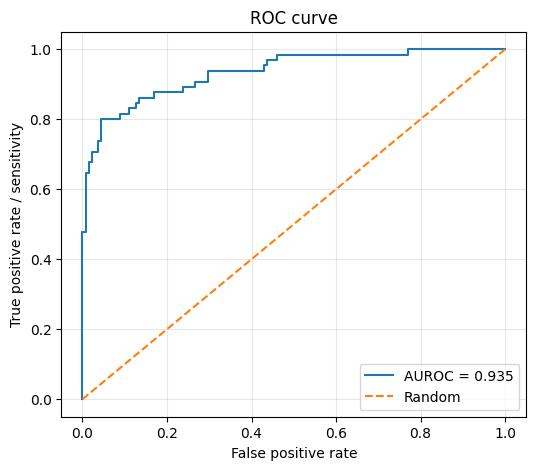

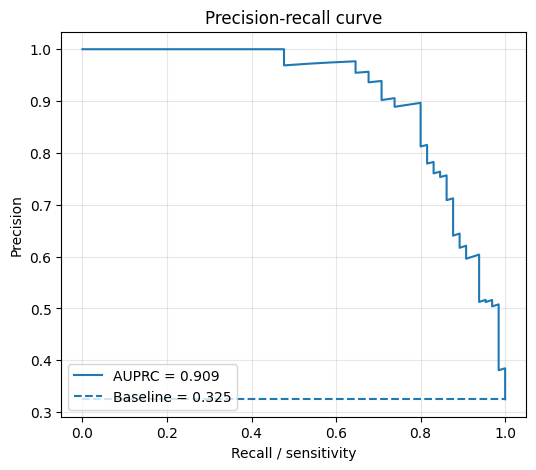

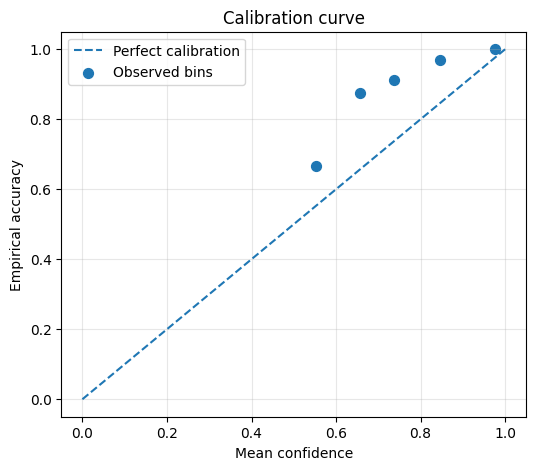

,bin,confidence_lower,confidence_upper,n,mean_confidence,empirical_accuracy,abs_gap
0,1,0.0,0.1,0,NaN,NaN,NaN
1,2,0.1,0.2,0,NaN,NaN,NaN
2,3,0.2,0.3,0,NaN,NaN,NaN
3,4,0.3,0.4,0,NaN,NaN,NaN
4,5,0.4,0.5,0,NaN,NaN,NaN
5,6,0.5,0.6,42,0.552278,0.666667,0.114388
6,7,0.6,0.7,40,0.656514,0.875000,0.218486
7,8,0.7,0.8,45,0.737624,0.911111,0.173487
8,9,0.8,0.9,34,0.845544,0.970588,0.125045
9,10,0.9,1.0,39,0.976281,1.000000,0.023719


In [19]:
print("Confusion matrix [[TN, FP], [FN, TP]]:")
print(confusion_matrix(y_demo, y_pred_demo, labels=[0, 1]))

plot_roc_curve(y_demo, probs_demo)
plot_precision_recall_curve(y_demo, probs_demo)
plot_calibration_curve(y_demo, probs_demo, n_bins=10)
calibration_table(y_demo, probs_demo, n_bins=10)

## 19. How to use this with your ECG standard neural network

If you have a standard PyTorch CNN called `standard_cnn`, use:

```python
standard_metrics, standard_y, standard_probs, standard_pred = evaluate_standard_nn_classifier(
    model=standard_cnn,
    data_loader=ts_test_loader,
    device=device,
    n_bins=10,
)

pd.DataFrame([standard_metrics], index=["standard CNN"])
```

The model must return logits of shape `[batch_size, 2]`.

## 20. How to use this with your ECG Bayesian neural network

If you have a Bayesian CNN called `bcnn` and guide called `bcnn_guide`, use:

```python
bayes_metrics, bayes_y, bayes_probs, bayes_pred = evaluate_bayesian_nn_classifier(
    model=bcnn,
    guide=bcnn_guide,
    data_loader=ts_test_loader,
    device=device,
    num_samples=100,
    n_bins=10,
    dataset_size=None,
)

pd.DataFrame([bayes_metrics], index=["Bayesian CNN"])
```

For training ELBO during minibatch training, `dataset_size` should usually be the full training-set size:

```python
train_dataset_size = len(ts_train_loader.dataset)
```

For held-out test-set reporting, using `dataset_size=None` gives an evaluation-style per-example estimate on the batches being evaluated.

## 21. Comparing a standard classifier and Bayesian classifier

Once both models have been evaluated, compare them side-by-side:

```python
comparison = pd.DataFrame(
    [standard_metrics, bayes_metrics],
    index=["standard CNN", "Bayesian CNN"],
)

comparison.T
```

Interpretation guidance:

| Metric | Better direction | What it emphasizes |
|---|---:|---|
| negative ELBO | lower | Bayesian posterior fit plus prior regularization |
| accuracy | higher | Overall hard-decision correctness |
| balanced accuracy | higher | Average performance across positive and negative classes |
| AUROC | higher | Ranking positives above negatives |
| AUPRC | higher | Positive-class retrieval, especially with imbalance |
| sensitivity | higher | Avoiding false negatives |
| specificity | higher | Avoiding false positives |
| negative log likelihood | lower | Probabilistic correctness; punishes confident errors |
| Brier score | lower | Mean squared probability error |
| expected calibration error | lower | Agreement between confidence and empirical accuracy |

For a medical classifier, raw accuracy is rarely enough. A Bayesian classifier may have similar accuracy to a standard classifier but better NLL, Brier score, ECE, or uncertainty behavior. That can still be valuable if uncertainty is clinically important.

## 22. Practical notes for Bayesian classifiers

### Use enough posterior samples

Bayesian predictions can be noisy if `num_samples` is small. For final evaluation, try values such as:

```python
num_samples = 100
num_samples = 250
num_samples = 500
```

and check whether the metrics stabilize.

### Calculate metrics from averaged probabilities

For Bayesian classifiers, do not calculate metrics from a single sampled network unless you specifically want to analyze one posterior draw. Usually, use:

$$
\bar p_i = \frac{1}{S}\sum_{s=1}^S p(y_i=1 \mid x_i, \theta^{(s)}).
$$

Then calculate accuracy, AUROC, AUPRC, NLL, Brier score, and ECE from \(\bar p_i\).

### Do not expect ELBO and accuracy to move identically

Negative ELBO optimizes probabilistic fit plus a KL penalty. Accuracy is a thresholded hard-decision metric. They are related but not equivalent.

### Report class prevalence

AUPRC and accuracy are easier to interpret when you also report:

$$
P(y=1).
$$

This notebook includes `positive_prevalence` in the metrics dictionary.